# Crypto Lab 02: Mathematical Foundations and Randomness

**CYBR 3570 - Applied Cryptography**  
**Toolkit Version:** `v0.2`

## Today's Big Question

**Why does cryptography need both mathematical structure and unpredictability?**

This week, your toolkit gains reusable math utilities and randomness utilities.

## Learning Objectives

By the end of this notebook, you should be able to compute modular operations, use GCDs and modular inverses, calculate simple entropy values, distinguish `random` from `secrets`, and demonstrate modulo bias.

## Setup

In [3]:
from __future__ import annotations

import math
import random
import secrets
from collections import Counter
from typing import Iterable

import matplotlib.pyplot as plt

## Part 1: Modular Arithmetic

Modular arithmetic is arithmetic with wraparound. In Python, `%` computes a remainder.

In [4]:
print(42 % 9)
print(-1 % 26)
print(27 % 26)

6
25
1


### Exercise 1.1: Modular Reduction

In [5]:
def mod_reduce(a: int, m: int) -> int:
    if m <= 0:
        raise ValueError("modulus must be positive")
    # TODO: return the least nonnegative residue of a modulo m
    return a % m

assert mod_reduce(42, 9) == 6
assert mod_reduce(-1, 26) == 25
assert mod_reduce(27, 26) == 1

### Exercise 1.2: Modular Operations

In [6]:
def mod_add(a: int, b: int, m: int) -> int:
    # TODO
    return (a + b) % m


def mod_mul(a: int, b: int, m: int) -> int:
    # TODO
    return (a * b) % m


def mod_pow(base: int, exponent: int, modulus: int) -> int:
    if exponent < 0:
        raise ValueError("negative exponents are not supported here")
    # TODO: use Python's efficient modular exponentiation
    return pow(base, exponent, modulus)

assert mod_add(8, 4, 9) == 3
assert mod_mul(6, 8, 9) == 3
assert mod_pow(3, 8, 7) == 2

### Reflection 1

Why is `pow(base, exponent, modulus)` preferable to computing `base ** exponent` and reducing afterward when the numbers are very large?

**Your answer:** becasue it allows modulus in the function which faster the take the nunber from ** and modulusing it. 

## Part 2: GCDs and Modular Inverses

A modular inverse of `a` modulo `m` is a number `x` such that `a*x == 1 mod m`. A modular inverse exists exactly when `gcd(a, m) = 1`.

In [7]:
def gcd(a: int, b: int) -> int:
    a, b = abs(a), abs(b)
    while b != 0:
        # TODO: update a and b
        a, b = b, a % b
    return a

assert gcd(15, 26) == 1
assert gcd(14, 26) == 2
assert gcd(0, 5) == 5

### Exercise 2.1: Extended GCD

In [8]:
def extended_gcd(a: int, b: int) -> tuple[int, int, int]:
    old_r, r = a, b
    old_s, s = 1, 0
    old_t, t = 0, 1
    while r != 0:
        quotient = old_r // r
        old_r, r = r, old_r - quotient * r
        old_s, s = s, old_s - quotient * s
        old_t, t = t, old_t - quotient * t
    return old_r, old_s, old_t

g, x, y = extended_gcd(15, 26)
print(g, x, y, 15*x + 26*y)
assert g == 1
assert 15*x + 26*y == g

1 7 -4 1


### Exercise 2.2: Modular Inverse

In [9]:
def mod_inverse(a: int, m: int) -> int:
    g, x, _ = extended_gcd(a, m)
    if g != 1:
        raise ValueError(f"{a} has no inverse modulo {m}")
    return x % m

assert mod_inverse(3, 26) == 9
assert mod_inverse(15, 26) == 7

try:
    mod_inverse(14, 26)
except ValueError as e:
    print("Expected error:", e)

Expected error: 14 has no inverse modulo 26


## Part 3: Affine Cipher Connection

The affine cipher encrypts letters using `y = ax + b mod 26`. To decrypt, we need `x = a^-1(y-b) mod 26`.

In [10]:
ALPHABET = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def char_to_num(ch: str) -> int:
    return ALPHABET.index(ch.upper())

def num_to_char(n: int) -> str:
    return ALPHABET[n % 26]

def affine_encrypt_char(ch: str, a: int, b: int) -> str:
    x = char_to_num(ch)
    y = (a * x + b) % 26
    return num_to_char(y)

def affine_decrypt_char(ch: str, a: int, b: int) -> str:
    y = char_to_num(ch)
    inv_a = mod_inverse(a, 26)
    x = inv_a * (y - b) % 26
    return num_to_char(x)

cipher = ''.join(affine_encrypt_char(c, 9, 13) for c in "ATTACK")
plain = ''.join(affine_decrypt_char(c, 9, 13) for c in cipher)
print(cipher, plain)

NCCNFZ ATTACK


### Reflection 2

Why is `a = 14` not a valid affine cipher multiplier modulo 26?

**Your answer:** 
It is not relitively prime to 26. gcd(14,26) = 2

## Part 4: Random-Looking vs Randomly Generated

The string `11010110` may look more random than `00000000`, but if both are possible outputs of a uniform 8-bit generator, each has probability `1/256`. Randomness is about the process, not just the appearance.

In [11]:
values = [secrets.randbits(8) for _ in range(10)]
print([format(v, '08b') for v in values])

['11100001', '11000000', '11100101', '10101101', '11100001', '10010111', '01011111', '01010001', '10101001', '11111110']


### Reflection 3

Suppose a secure generator outputs `00000000`. Should we immediately conclude the generator is broken? Explain.

**Your answer:**
NO. that is a valid random value.

## Part 5: Entropy

Entropy measures uncertainty in a probability distribution: `H = -sum(p * log2(p))`. A fair coin has 1 bit of entropy. A biased coin has less.

In [12]:
def entropy(probabilities: Iterable[float]) -> float:
    total = 0.0
    for p in probabilities:
        if p < 0:
            raise ValueError("probabilities cannot be negative")
        if p == 0:
            continue
        total -= p * math.log2(p)
    return total

print("Fair coin:", entropy([0.5, 0.5]))
print("Biased coin:", entropy([0.25, 0.75]))
print("Very biased coin:", entropy([0.01, 0.99]))
print("Uniform byte:", entropy([1/256] * 256))

Fair coin: 1.0
Biased coin: 0.8112781244591328
Very biased coin: 0.08079313589591118
Uniform byte: 8.0


### Exercise 5.1

Compute the entropy of a fair six-sided die and a loaded die with probabilities `[0.5, 0.1, 0.1, 0.1, 0.1, 0.1]`.

In [13]:
fair_die_entropy = entropy([1/6] * 6)
loaded_die_entropy = entropy([0.5, 0.1, 0.1, 0.1, 0.1, 0.1])
print("Fair die entropy:", fair_die_entropy)
print("Loaded die entropy:", loaded_die_entropy)

Fair die entropy: 2.584962500721156
Loaded die entropy: 2.1609640474436813


## Part 6: Python `random` vs `secrets`

Python's `random` module is useful for simulations and testing. It is not designed for cryptographic security. For security-sensitive values, use `secrets` or a vetted cryptographic library.

In [14]:
print("random:", [random.randint(0, 100) for _ in range(5)])
print("secrets:", [secrets.randbelow(101) for _ in range(5)])
print("token:", secrets.token_hex(16))

random: [5, 52, 100, 82, 44]
secrets: [0, 49, 24, 99, 99]
token: b6af933992ca830be2b9af53b2680168


### Demonstration: Deterministic Seeding

In [15]:
random.seed(3570)
first = [random.randint(0, 1000000) for _ in range(5)]
random.seed(3570)
second = [random.randint(0, 1000000) for _ in range(5)]
print(first)
print(second)
print("Same sequence?", first == second)

[22193, 332748, 718419, 365861, 100656]
[22193, 332748, 718419, 365861, 100656]
Same sequence? True


### Reflection 4

Why is deterministic seeding useful in scientific experiments but dangerous when generating cryptographic keys?

**Your answer:**
repeatability when testing an equaton with random but don't want seeded random keys.

## Part 7: Modulo Bias

Suppose we want a random decimal digit from 0 to 9. A byte has 256 possible values. If we compute `random_byte % 10`, digits 0-5 occur 26 times each while digits 6-9 occur 25 times each.

In [16]:
def biased_digit() -> int:
    return secrets.randbits(8) % 10

def unbiased_digit() -> int:
    while True:
        x = secrets.randbits(8)
        if x < 250:
            return x % 10

def sample_counts(fn, n: int = 100_000) -> Counter:
    return Counter(fn() for _ in range(n))

biased_counts = sample_counts(biased_digit)
unbiased_counts = sample_counts(unbiased_digit)
print("Biased:", biased_counts)
print("Unbiased:", unbiased_counts)

Biased: Counter({4: 10270, 2: 10268, 0: 10175, 1: 10071, 5: 10059, 3: 10040, 7: 9902, 9: 9852, 6: 9706, 8: 9657})
Unbiased: Counter({1: 10138, 5: 10069, 7: 10035, 2: 10005, 3: 10001, 9: 9995, 0: 9980, 4: 9946, 8: 9926, 6: 9905})


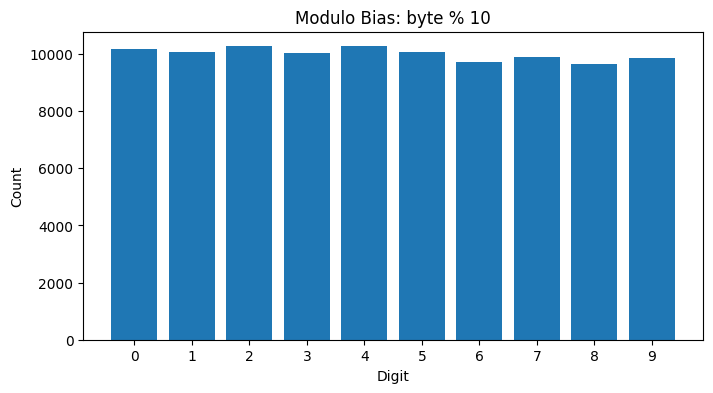

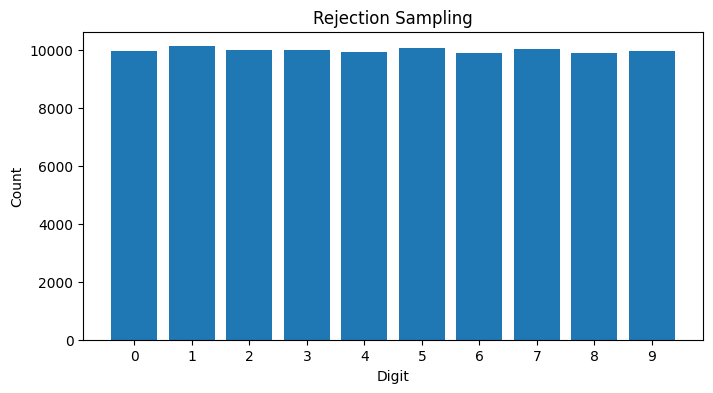

In [17]:
def plot_counts(counts: Counter, title: str) -> None:
    xs = list(range(10))
    ys = [counts[x] for x in xs]
    plt.figure(figsize=(8, 4))
    plt.bar(xs, ys)
    plt.xticks(xs)
    plt.title(title)
    plt.xlabel("Digit")
    plt.ylabel("Count")
    plt.show()

plot_counts(biased_counts, "Modulo Bias: byte % 10")
plot_counts(unbiased_counts, "Rejection Sampling")

### Exercise 7.1

Use `secrets.randbelow(10)` to generate unbiased random digits. Compare its distribution to rejection sampling.

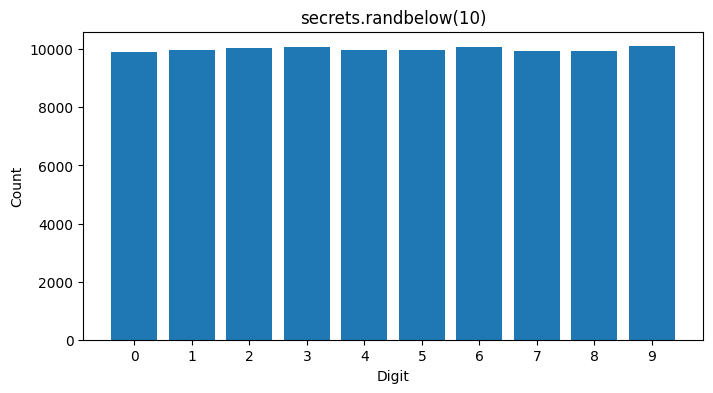

In [18]:
def secrets_digit() -> int:
    # TODO
    return secrets.randbelow(10)

secrets_counts = sample_counts(secrets_digit)
plot_counts(secrets_counts, "secrets.randbelow(10)")

## Part 8: Toolkit Integration

Add the following modules to your toolkit:

```text
crypto_toolkit/math/modular.py
crypto_toolkit/math/gcd.py
crypto_toolkit/utilities/randomness.py
```

Then run `python -m pytest`.

In [19]:
# Optional integration check after creating the modules.
# from crypto_toolkit.math.modular import mod_reduce, mod_add, mod_mul, mod_pow
# from crypto_toolkit.math.gcd import gcd, extended_gcd, mod_inverse
# from crypto_toolkit.utilities.randomness import secure_token_hex, secure_randbelow

## Engineering Log Entry

Add a Week 2 entry to `ENGINEERING_LOG.md`:

1. Which modules did you add?
2. Which mathematical function was most difficult to understand?
3. What is one way randomness can fail in a cryptographic system?
4. What is one rule you will follow when generating random values in future projects?

## Final Reflection

Return to today's big question:

**Why does cryptography need both mathematical structure and unpredictability?**

Write a paragraph connecting modular arithmetic, inverses, entropy, and secure random generation.

Cryptography needs mathematical structure to make encryption and decryption reversible in a controlled way, and it needs unpredictability to make that reversal impossible without the key. Modular arithmetic supplies the structure: operations like exponentiation modulo a large prime create functions that are easy to compute in one direction but computationally infeasible to invert without extra information, while modular inverses give the precise mechanism for undoing an operation dividing modulo n only works if you can find a number that, multiplied by your value, returns 1 mod n, and this is exactly what lets a private key "undo" what a public key did, or what lets decryption recover plaintext from ciphertext. Unpredictability brings the diffculty to cryptography turning simple and elgat math into a nightmare for a hacker to break into making something that the hacker can just guess into something that is nearly impossible to guess whithout knowing how the person got randomness. 

## Submission Checklist

- [ ] All notebook cells run from top to bottom.
- [ ] Modular arithmetic assertions pass.
- [ ] GCD and modular inverse assertions pass.
- [ ] Entropy examples run correctly.
- [ ] Modulo bias plots are generated.
- [ ] Toolkit has been updated to v0.2.
- [ ] `pytest` passes from the project root.
- [ ] Changes are committed and pushed.